In [ ]:
from PIL import Image
from numpy import asarray
from os import listdir
import matplotlib.pyplot as plt
import torch
from torch import nn
from torchsummary import summary
import numpy as np
from torch import optim
import os

In [ ]:
def load_image(filename):
    image = Image.open(filename)
    image = image.convert('RGB')
    pixels = asarray(image)
    return pixels

In [ ]:
def load_faces(directory, n_faces):
    faces = list()
    for filename in listdir(directory):
        pixels = load_image(directory + filename)
        faces.append(pixels)
        if len(faces) >= n_faces:
            break
    return asarray(faces)

In [ ]:
def plot_faces(faces, n):
    for i in range(n * n):
        plt.subplot(n, n, 1 + i)
        plt.axis('off')
        plt.imshow(faces[i])
    plt.show()

In [ ]:
directory = 'data/img_align_celeba/'
faces = load_faces(directory, 25)
print(faces.shape)
plot_faces(faces, 5)

In [ ]:
import mtcnn
print(mtcnn.__version__)

In [ ]:
def extract_face(model, pixels, required_size=(80, 80)):
    # detect face in the image
    faces = model.detect_faces(pixels)
    # skip cases where we could not detect a face
    if len(faces) == 0:
        return None
    # extract details of the face
    x1, y1, width, height = faces[0]["box"]
    # force detected pixel values to be positive (bug fix)
    x1, y1 = abs(x1), abs(y1)
    # convert into coordinates
    x2, y2 = x1 + width, y1 + height
    # retrieve face pixels
    face_pixels = pixels[y1:y2, x1:x2]
    # resize pixels to the model size
    image = Image.fromarray(face_pixels)
    image = image.resize(required_size)
    face_array = asarray(image)
    return face_array

In [ ]:
def load_faces(directory, n_faces):
    # prepare model
    model = mtcnn.MTCNN()
    faces = list()
    for filename in listdir(directory):
        # load the image
        pixels = load_image(directory + filename)
        # get face
        face = extract_face(model, pixels)
        if face is None:
            continue
        # store
        faces.append(face)
        # stop once we have enough
        if len(faces) >= n_faces:
            break
    return asarray(faces)

In [ ]:
from numpy import savez_compressed

all_faces = load_faces(directory, 5000)
print(all_faces.shape)
savez_compressed("data/img_align_celeba.npz", all_faces)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 128, 5, padding='same')
        self.lrelu = nn.LeakyReLU(0.2)
        self.conv2 = nn.Conv2d(128, 128, 5, 2, padding=1)
        self.conv3 = nn.Conv2d(128, 128, 5, 2, padding=1)
        self.conv4 = nn.Conv2d(128, 128, 5, 2, padding=1)
        self.conv5 = nn.Conv2d(128, 128, 5, 2, padding=1)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.4)
        self.ll1 = nn.LazyLinear(1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        out = self.lrelu(self.conv1(x))
        out = self.lrelu(self.conv2(out))
        out = self.lrelu(self.conv3(out))
        out = self.lrelu(self.conv4(out))
        out = self.lrelu(self.conv5(out))
        out = self.dropout(self.flatten(out))
        out = self.ll1(out)
        return self.sigmoid(out)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
discriminator = Discriminator().to(device)
summary(discriminator, (3, 80, 80))

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.ll1 = nn.Linear(latent_dim, 128*5*5)
        self.lrelu = nn.LeakyReLU(0.2)
        self.conv1 = nn.ConvTranspose2d(128, 128, 4, 2, padding=1)
        self.conv2 = nn.ConvTranspose2d(128, 128, 4, 2, padding=1)
        self.conv3 = nn.ConvTranspose2d(128, 128, 4, 2, padding=1)
        self.conv4 = nn.ConvTranspose2d(128, 128, 4, 2, padding=1)
        self.conv5 = nn.Conv2d(128, 3, 5, padding='same')
        self.tanh = nn.Tanh()
    
    def forward(self, x):
        out = self.lrelu(self.ll1(x))
        out = out.view(-1, 128, 5, 5)
        out = self.lrelu(self.conv1(out))
        out = self.lrelu(self.conv2(out))
        out = self.lrelu(self.conv3(out))
        out = self.lrelu(self.conv4(out))
        out = self.conv5(out)
        return self.tanh(out)

In [ ]:
generator = Generator(100).to(device)
summary(generator, (100,))

In [ ]:
def load_real_samples():
    # load the face dataset
    data = np.load('data/img_align_celeba.npz')
    X = data['arr_0']
    # convert from unsigned ints to floats
    X = X.astype('float32')
    # scale from [0,255] to [-1,1]
    X = (X- 127.5) / 127.5
    return X

In [ ]:
def generate_real_samples(dataset, n_samples):
    ix = np.random.randint(0, dataset.shape[0], n_samples)
    X = dataset[ix]
    y = np.ones(((n_samples), 1))
    return X, y

In [ ]:
def generate_latent_points(latent_dim, n_samples):
    x_input = np.random.randn(latent_dim * n_samples)
    x_input = x_input.reshape(n_samples, latent_dim)
    return x_input

In [ ]:
def generate_fake_samples(g_model, latent_dim, n_samples):
    x_input = generate_latent_points(latent_dim, n_samples)
    X = g_model(torch.Tensor(x_input).to(device))
    y = torch.zeros((n_samples, 1))
    return X, y

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        m.weight.data.normal_(0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)

In [ ]:
LATENT_DIM = 100
N_BATCH = 128
NUM_EPOCHS = 100
LR = 2e-4

In [ ]:
netG = Generator(100).to(device)
netG.apply(weights_init)

netD = Discriminator().to(device)
netD.apply(weights_init)

criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(0.5, 0.999))

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
dataset = TensorDataset(torch.Tensor(load_real_samples()))
dataloader = DataLoader(dataset, batch_size = N_BATCH//2, shuffle=True, drop_last=True)

In [ ]:
def save_image(img_list, epoch):
    plt.figure(figsize=(16, 16));
    plt.axis("off")
    plt.imshow(np.transpose(img_list[-1], (1, 2, 0)))
    if not os.path.exists('generated'):
        os.makedirs('generated')
    plt.savefig("generated/img%d.png" % epoch, bbox_inches='tight', pad_inches=0)  

In [ ]:
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import torchvision.utils as vutils

img_list = []
iters = 0

viz_noise = torch.Tensor(generate_latent_points(LATENT_DIM, N_BATCH//2)).to(device)

now = datetime.now()
timestamp = now.strftime("%Y%m%d-%H%M%S")
logdir = f"trainings/{timestamp}/"
writer = SummaryWriter(logdir)
global_step = 0

for epoch in range(NUM_EPOCHS):
    batch_iterator = tqdm(dataloader, desc=f"Processing Epoch {epoch+1:02d}")
    torch.cuda.empty_cache()
    for i, data in enumerate(batch_iterator):
        netD.train()
        netG.train()

        netD.zero_grad()
        x_real = data[0].to(device) # tuple (IMG, N°.)
        b_size = x_real.size(0)
        x_real = x_real.permute(0, 3, 1, 2)
        label = torch.full((b_size,), 1, dtype=torch.float, device=device)
        output = netD(x_real).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()

        fake, _ = generate_fake_samples(netG, LATENT_DIM, N_BATCH//2)
        output = netD(torch.Tensor(fake).to(device).detach()).view(-1)
        label.fill_(0)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        errD = errD_real + errD_fake
        optimizerD.step()

        netG.zero_grad()
        label.fill_(1)
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

        writer.add_scalars('losses', {'DLoss': errD.item(), 'GLoss': errG.item()}, global_step)
        writer.flush()
        global_step += 1
        if (iters % 500 == 0) or ((epoch == NUM_EPOCHS-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(viz_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))
        iters += 1
    if epoch % 5 == 0:
        save_image(img_list, epoch)

In [ ]:
torch.save(netG.state_dict(),"data/netG_model.pt")
torch.save(netD.state_dict(), "data/netD_model.pt")

In [ ]:
real_batch = next(iter(dataloader))

plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].permute(0, 3, 1 ,2).to(device)[:80], padding=5, normalize=True).cpu(),(1,2,0)))

plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()

In [ ]:
def interpolate_points(p1, p2, n_steps=10):
    ratios = np.linspace(0, 1, num=n_steps)
    vectors = list()
    for ratio in ratios:
        v = (1 - ratio) * p1 + ratio * p2
        vectors.append(v)
    return asarray(vectors)

In [ ]:
def plot_generated(examples, n):
    # plot images
    for i in range(n * n):
        # define subplot
        plt.subplot(n, n, 1 + i)
        # turn off axis
        plt.axis("off")
        # plot raw pixel data
        plt.imshow(examples[i, :, :])
    plt.show()

In [ ]:
model_weight = torch.load('data/netG_model.pt')
model = Generator(100).to(device)
model.load_state_dict(model_weight)
model.eval()
pts = generate_latent_points(100, 20)
results = None
for i in range(0, 20, 2):
    interpolated = interpolate_points(pts[i], pts[i+1])
    output = model(torch.Tensor(interpolated).to(device))
    if results is None:
        results = ((output + 1)/2).permute(0,2,3,1).detach().cpu()
    else:
        results = np.vstack((results, ((output + 1)/2).permute(0,2,3,1).detach().cpu()))
plot_generated(results, 10)

In [ ]:
def plot_generated(examples, n):
    # plot images
    for i in range(n * n):
        # define subplot
        plt.subplot(n, n, 1 + i)
        # turn off axis
        plt.axis('off')
        # plot raw pixel data
        plt.imshow(examples[i, :, :])
    plt.savefig('generated/generated_faces.png')
    plt.close()

In [ ]:
latent_points = generate_latent_points(100, 100)
savez_compressed('data/latent_points.npz', latent_points)
x = model(torch.Tensor(latent_points).to(device))
x = (x+1)/2
plot_generated(x.permute(0,2,3,1).detach().cpu(), 10)

In [ ]:
smiling_woman_ix = [1, 3, 90]
neutral_woman_ix = [53, 58, 66]
neutral_man_ix = [42, 52, 100]
data = np.load('data/latent_points.npz')
points = data['arr_0']

In [ ]:
def average_points(points, ix):
    # convert to zero offset points
    zero_ix = [i-1 for i in ix]
    # retrieve required points
    vectors = points[zero_ix]
     # average the vectors
    avg_vector = np.mean(vectors, axis=0)
    # combine original and avg vectors
    all_vectors = np.vstack((vectors, avg_vector))
    return all_vectors

In [ ]:
smiling_woman = average_points(points, smiling_woman_ix)
neutral_woman = average_points(points, neutral_woman_ix)
neutral_man = average_points(points, neutral_man_ix)

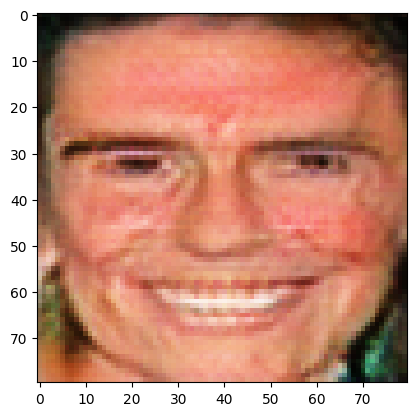

In [178]:
result_vector = smiling_woman[-1]- neutral_woman[-1] + neutral_man[-1]
result_vector = np.expand_dims(result_vector, 0)
x = model(torch.Tensor(result_vector).to(device))
x = (x+1)/2
plt.imshow(x.squeeze(0).permute(1,2,0).detach().cpu())